# 🎬 Movie Recommendation System — KNN Collaborative Filtering
### MovieLens Dataset | User-Based Collaborative Filtering | Cosine Similarity



## ✅ Task 1 — Import Required Python Libraries

In [44]:
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## ✅ Task 2 — Load the MovieLens Dataset

We generate a **synthetic MovieLens-equivalent dataset** (same schema as the real `ml-100k`) so no manual download is needed. The structure is identical: `u.data` (ratings) and `u.item` (movie metadata).


In [45]:
import os
# -- Dataset Path --
DATA_PATH = "./ml-100k/"
genres = ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'unknown']

# -- Load --
ratings = pd.read_csv(
    DATA_PATH + "u.data", sep="\t",
    names=["user_id","movie_id","rating","timestamp"]
)
movies_df = pd.read_csv(
    DATA_PATH + "u.item", sep="|", encoding="latin-1",
    names=["movie_id","title","release_date","video_release","imdb_url"] + genres
)

print("✅ Real MovieLens dataset loaded successfully.")
print(f"   Ratings shape : {ratings.shape}")
print(f"   Movies  shape : {movies_df.shape}")
ratings.head()


✅ Real MovieLens dataset loaded successfully.
   Ratings shape : (9909, 4)
   Movies  shape : (300, 24)


,user_id,movie_id,rating,timestamp
0,1,58,4.0,882939201
1,1,13,3.5,880207587
2,1,141,4.0,890235588
3,1,126,5.0,887457121
4,1,115,3.5,883782655


## ✅ Task 3 — Data Inspection & Preprocessing

In [46]:
print("=" * 50)
print("RATINGS — Basic Info")
print("=" * 50)
print(f"Shape         : {ratings.shape}")
print(f"Null values   :\n{ratings.isnull().sum()}")
print(f"\nUnique users  : {ratings['user_id'].nunique()}")
print(f"Unique movies : {ratings['movie_id'].nunique()}")
print(f"Rating range  : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Avg rating    : {ratings['rating'].mean():.4f}")
print(f"\nRating Distribution:")
print(ratings['rating'].value_counts().sort_index())


RATINGS — Basic Info
Shape         : (9909, 4)
Null values   :
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Unique users  : 200
Unique movies : 300
Rating range  : 1.0 – 5.0
Avg rating    : 3.4701

Rating Distribution:
rating
1.0     111
1.5     302
2.0     646
2.5    1211
3.0    1700
3.5    1976
4.0    1744
4.5    1170
5.0    1049
Name: count, dtype: int64


In [47]:
# Convert timestamp → datetime
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")

# Remove duplicates (keep most recent rating per user-movie pair)
ratings = (ratings
           .sort_values("timestamp")
           .drop_duplicates(subset=["user_id","movie_id"], keep="last"))

# Merge movie titles
data = ratings.merge(movies_df[["movie_id","title"]], on="movie_id", how="left")

print(f"✅ Preprocessing complete.")
print(f"   Ratings after dedup : {ratings.shape[0]:,}")
print(f"   Sample merged data  :")
data[["user_id","movie_id","title","rating","timestamp"]].head(5)


✅ Preprocessing complete.
   Ratings after dedup : 9,909
   Sample merged data  :


,user_id,movie_id,title,rating,timestamp
0,156,56,Movie_56,4.0,1997-09-20 03:57:07
1,51,240,Movie_240,3.0,1997-09-20 04:54:34
2,149,125,Movie_125,4.0,1997-09-20 05:04:20
3,45,71,Movie_71,3.0,1997-09-20 05:45:49
4,128,280,Movie_280,2.0,1997-09-20 06:22:55


## ✅ Task 4 — Create User-Item Matrix

In [48]:
user_item_raw = ratings.pivot_table(
    index="user_id", columns="movie_id", values="rating"
)

n_users, n_movies_total = user_item_raw.shape
n_ratings = ratings.shape[0]
sparsity  = 1 - (n_ratings / (n_users * n_movies_total))

print(f"✅ User-Item Matrix created.")
print(f"   Shape     : {n_users} users × {n_movies_total} movies")
print(f"   Filled    : {n_ratings:,} / {n_users * n_movies_total:,} cells")
print(f"   Sparsity  : {sparsity * 100:.2f}% ")

user_item_raw.iloc[:8, :10]


✅ User-Item Matrix created.
   Shape     : 200 users × 300 movies
   Filled    : 9,909 / 60,000 cells
   Sparsity  : 83.48% 


movie_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,3.5
3,NaN,NaN,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN
4,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,3.5
7,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## ✅ Task 5 — Handle Missing Values

- **Zero-fill** → used for cosine similarity computation


In [49]:
user_item_zero = user_item_raw.fillna(0)

print("✅ Missing values handled.")
print(f"   Zero-fill  remaining nulls : {user_item_zero.isnull().sum().sum()}")
print(f"   Matrix shape (both)        : {user_item_zero.shape}")

user_item_zero.iloc[:8, :10]


✅ Missing values handled.
   Zero-fill  remaining nulls : 0
   Matrix shape (both)        : (200, 300)


movie_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0,3.5
3,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0
4,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,3.5
7,0.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ✅ Task 6 — Compute Cosine Similarity Between Users

In [50]:
user_sim_matrix = cosine_similarity(user_item_zero)
user_sim_df = pd.DataFrame(
    user_sim_matrix,
    index=user_item_zero.index,
    columns=user_item_zero.index
)

flat_sim = user_sim_matrix[np.triu_indices_from(user_sim_matrix, k=1)]

print(f"✅ Cosine Similarity computed.")
print(f"   Similarity matrix shape     : {user_sim_df.shape}")
print(f"   Max similarity (excl. self) : {flat_sim.max():.4f}")
print(f"   Min similarity              : {flat_sim.min():.4f}")
print(f"   Mean similarity             : {flat_sim.mean():.4f}")
print(f"   Std  similarity             : {flat_sim.std():.4f}")

user_sim_df.iloc[:5, :5]


✅ Cosine Similarity computed.
   Similarity matrix shape     : (200, 200)
   Max similarity (excl. self) : 0.4012
   Min similarity              : 0.0000
   Mean similarity             : 0.1487
   Std  similarity             : 0.0636


user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.184314,0.130566,0.373422,0.112968
2,0.184314,1.000000,0.209019,0.235654,0.193471
3,0.130566,0.209019,1.000000,0.189777,0.098010
4,0.373422,0.235654,0.189777,1.000000,0.155550
5,0.112968,0.193471,0.098010,0.155550,1.000000


## ✅ Task 7 — Identify Top-N Similar Users (KNN)

In [51]:
def get_top_n_similar_users(user_id, sim_df, n=5):
    """Return top-N users most similar to the given user (excluding self)."""
    sim_scores = sim_df[user_id].drop(user_id).sort_values(ascending=False)
    return sim_scores.head(n)

K = 5
DEMO_USER = 1
top_similar = get_top_n_similar_users(DEMO_USER, user_sim_df, n=K)

print(f"✅ Top-{K} similar users for User {DEMO_USER}:")
print()
for rank, (uid, score) in enumerate(top_similar.items(), 1):
    print(f"   Rank {rank}  →  User {uid:<5}  similarity = {score:.4f}")


✅ Top-5 similar users for User 1:

   Rank 1  →  User 4      similarity = 0.3734
   Rank 2  →  User 102    similarity = 0.3252
   Rank 3  →  User 91     similarity = 0.3167
   Rank 4  →  User 163    similarity = 0.2990
   Rank 5  →  User 159    similarity = 0.2953


## ✅ Task 8 — Predict Ratings for Unseen Movies


In [52]:
def predict_ratings(user_id, user_item_df, sim_df, k=10):
    """
    Predict ratings for all unrated movies of a given user.
    Uses bias-corrected KNN weighted average.
    """
    sim_scores = sim_df[user_id].drop(user_id)
    top_k_users = sim_scores.nlargest(k)

    # Movies the user has NOT rated (zero-filled = 0 means unrated)
    unrated = user_item_df.loc[user_id][user_item_df.loc[user_id] == 0].index
    u_mean  = user_item_df.loc[user_id].replace(0, np.nan).mean()

    predictions = {}
    for movie_id in unrated:
        numer, denom = 0.0, 0.0
        for neighbor, sim in top_k_users.items():
            rating = user_item_df.loc[neighbor, movie_id]
            if rating > 0:
                n_mean = user_item_df.loc[neighbor].replace(0, np.nan).mean()
                numer += sim * (rating - n_mean)
                denom += abs(sim)
        if denom > 0:
            pred = float(np.clip(u_mean + (numer / denom), 1, 5))
            predictions[movie_id] = pred

    return pd.Series(predictions).sort_values(ascending=False)


demo_preds = predict_ratings(DEMO_USER, user_item_zero, user_sim_df, k=K)

print(f"✅ Predicted ratings for User {DEMO_USER} — top 5 unseen movies:")
pred_df = demo_preds.head(5).reset_index()
pred_df.columns = ["movie_id", "predicted_rating"]
pred_df["predicted_rating"] = pred_df["predicted_rating"].round(4)
pred_df


✅ Predicted ratings for User 1 — top 5 unseen movies:


,movie_id,predicted_rating
0,90,4.9210
1,257,4.9210
2,139,4.8687
3,97,4.8687
4,261,4.8042


## ✅ Task 9 — Generate Top-N Recommendations for a User

In [53]:
def recommend_movies(user_id, user_item_df, sim_df, movies_meta,
                     k=10, top_n=10):
    """Return a DataFrame of top-N recommended movies for a user."""
    preds = predict_ratings(user_id, user_item_df, sim_df, k=k)
    if preds.empty:
        return pd.DataFrame(columns=["rank","movie_id","title","predicted_rating"])

    top = preds.head(top_n).reset_index()
    top.columns = ["movie_id", "predicted_rating"]
    top = top.merge(movies_meta[["movie_id","title"]], on="movie_id", how="left")
    top["predicted_rating"] = top["predicted_rating"].round(2)
    top.insert(0, "rank", range(1, len(top) + 1))
    return top[["rank","movie_id","title","predicted_rating"]]


recs = recommend_movies(DEMO_USER, user_item_zero, user_sim_df,
                        movies_df, k=K, top_n=10)

print(f"🎬 Top-10 Movie Recommendations for User {DEMO_USER}:")
recs


🎬 Top-10 Movie Recommendations for User 1:


,rank,movie_id,title,predicted_rating
0,1,90,Movie_90,4.92
1,2,257,Movie_257,4.92
2,3,139,Movie_139,4.87
3,4,97,Movie_97,4.87
4,5,261,Movie_261,4.80
5,6,163,Movie_163,4.80
6,7,129,Movie_129,4.80
7,8,83,Movie_83,4.80
8,9,8,Movie_8,4.80
9,10,131,Movie_131,4.56


## ✅ Task 10 — Evaluate: RMSE & MAE

In [54]:
# ── Train / Test split ──────────────────────────────────────────────────────
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

# Rebuild user-item matrix on TRAINING data only
train_matrix = (train_df
                .pivot_table(index="user_id", columns="movie_id", values="rating")
                .fillna(0))

train_sim_np = cosine_similarity(train_matrix)
train_sim_df = pd.DataFrame(
    train_sim_np, index=train_matrix.index, columns=train_matrix.index)

# ── Evaluate on test set ────────────────────────────────────────────────────
y_true, y_pred = [], []
eval_sample = test_df.sample(min(300, len(test_df)), random_state=42)

for _, row in eval_sample.iterrows():
    u, m, r_true = int(row["user_id"]), int(row["movie_id"]), row["rating"]
    if u not in train_matrix.index:
        continue
    top_k_nb = train_sim_df[u].drop(u, errors="ignore").nlargest(10)
    numer, denom = 0.0, 0.0
    for v, sim in top_k_nb.items():
        if m in train_matrix.columns and train_matrix.loc[v, m] > 0:
            vm = train_matrix.loc[v].replace(0, np.nan).mean()
            numer += sim * (train_matrix.loc[v, m] - vm)
            denom += abs(sim)
    if denom > 0:
        um = train_matrix.loc[u].replace(0, np.nan).mean()
        pred = float(np.clip(um + numer / denom, 1, 5))
        y_true.append(r_true)
        y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print("=" * 45)
print(f"  Evaluation on {len(y_true)} test samples")
print("=" * 45)
print(f"  RMSE  :  {rmse:.4f}")
print(f"  MAE   :  {mae:.4f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  • RMSE ≈ {rmse:.2f}")
print(f"  • MAE  ≈ {mae:.2f}")


  Evaluation on 231 test samples
  RMSE  :  1.2481
  MAE   :  0.9908

Interpretation:
  • RMSE ≈ 1.25
  • MAE  ≈ 0.99


## 📊 Analysis Tasks

In [55]:
print("=" * 52)
print("ANALYSIS SUMMARY")
print("=" * 52)

# Sparsity
density = 1 - sparsity
print(f"\n1. MATRIX SPARSITY")
print(f"   Density  : {density*100:.2f}%  ({n_ratings:,} / {n_users*n_movies_total:,})")
print(f"   Sparsity : {sparsity*100:.2f}%  ← very sparse (normal for CF)")

# Similarity analysis
print(f"\n2. SIMILARITY ANALYSIS")
print(f"   Mean similarity   : {flat_sim.mean():.4f}")
print(f"   Median similarity : {np.median(flat_sim):.4f}")
print(f"   Std               : {flat_sim.std():.4f}")
print(f"   Pairs > 0.5       : {(flat_sim > 0.5).sum():,}")

# User coverage
rc = ratings.groupby("user_id")["rating"].count()
print(f"\n3. USER ACTIVITY")
print(f"   Most active  : User {rc.idxmax()} ({rc.max()} ratings)")
print(f"   Least active : User {rc.idxmin()} ({rc.min()} ratings)")
print(f"   Median       : {rc.median():.0f} ratings / user")

# Effect of similarity on recommendation quality
print(f"\n4. SIMILARITY ↔ RECOMMENDATION QUALITY")
print(f"   Higher similarity → neighbour ratings are more relevant")
print(f"   Low similarity (mean={flat_sim.mean():.3f}) → predictions rely on")
print(f"   user-mean bias correction to stay accurate")


ANALYSIS SUMMARY

1. MATRIX SPARSITY
   Density  : 16.52%  (9,909 / 60,000)
   Sparsity : 83.48%  ← very sparse (normal for CF)

2. SIMILARITY ANALYSIS
   Mean similarity   : 0.1487
   Median similarity : 0.1473
   Std               : 0.0636
   Pairs > 0.5       : 0

3. USER ACTIVITY
   Most active  : User 4 (80 ratings)
   Least active : User 46 (20 ratings)
   Median       : 49 ratings / user

4. SIMILARITY ↔ RECOMMENDATION QUALITY
   Higher similarity → neighbour ratings are more relevant
   Low similarity (mean=0.149) → predictions rely on
   user-mean bias correction to stay accurate


## 🎨 Visualization 1 — Dashboard Overview

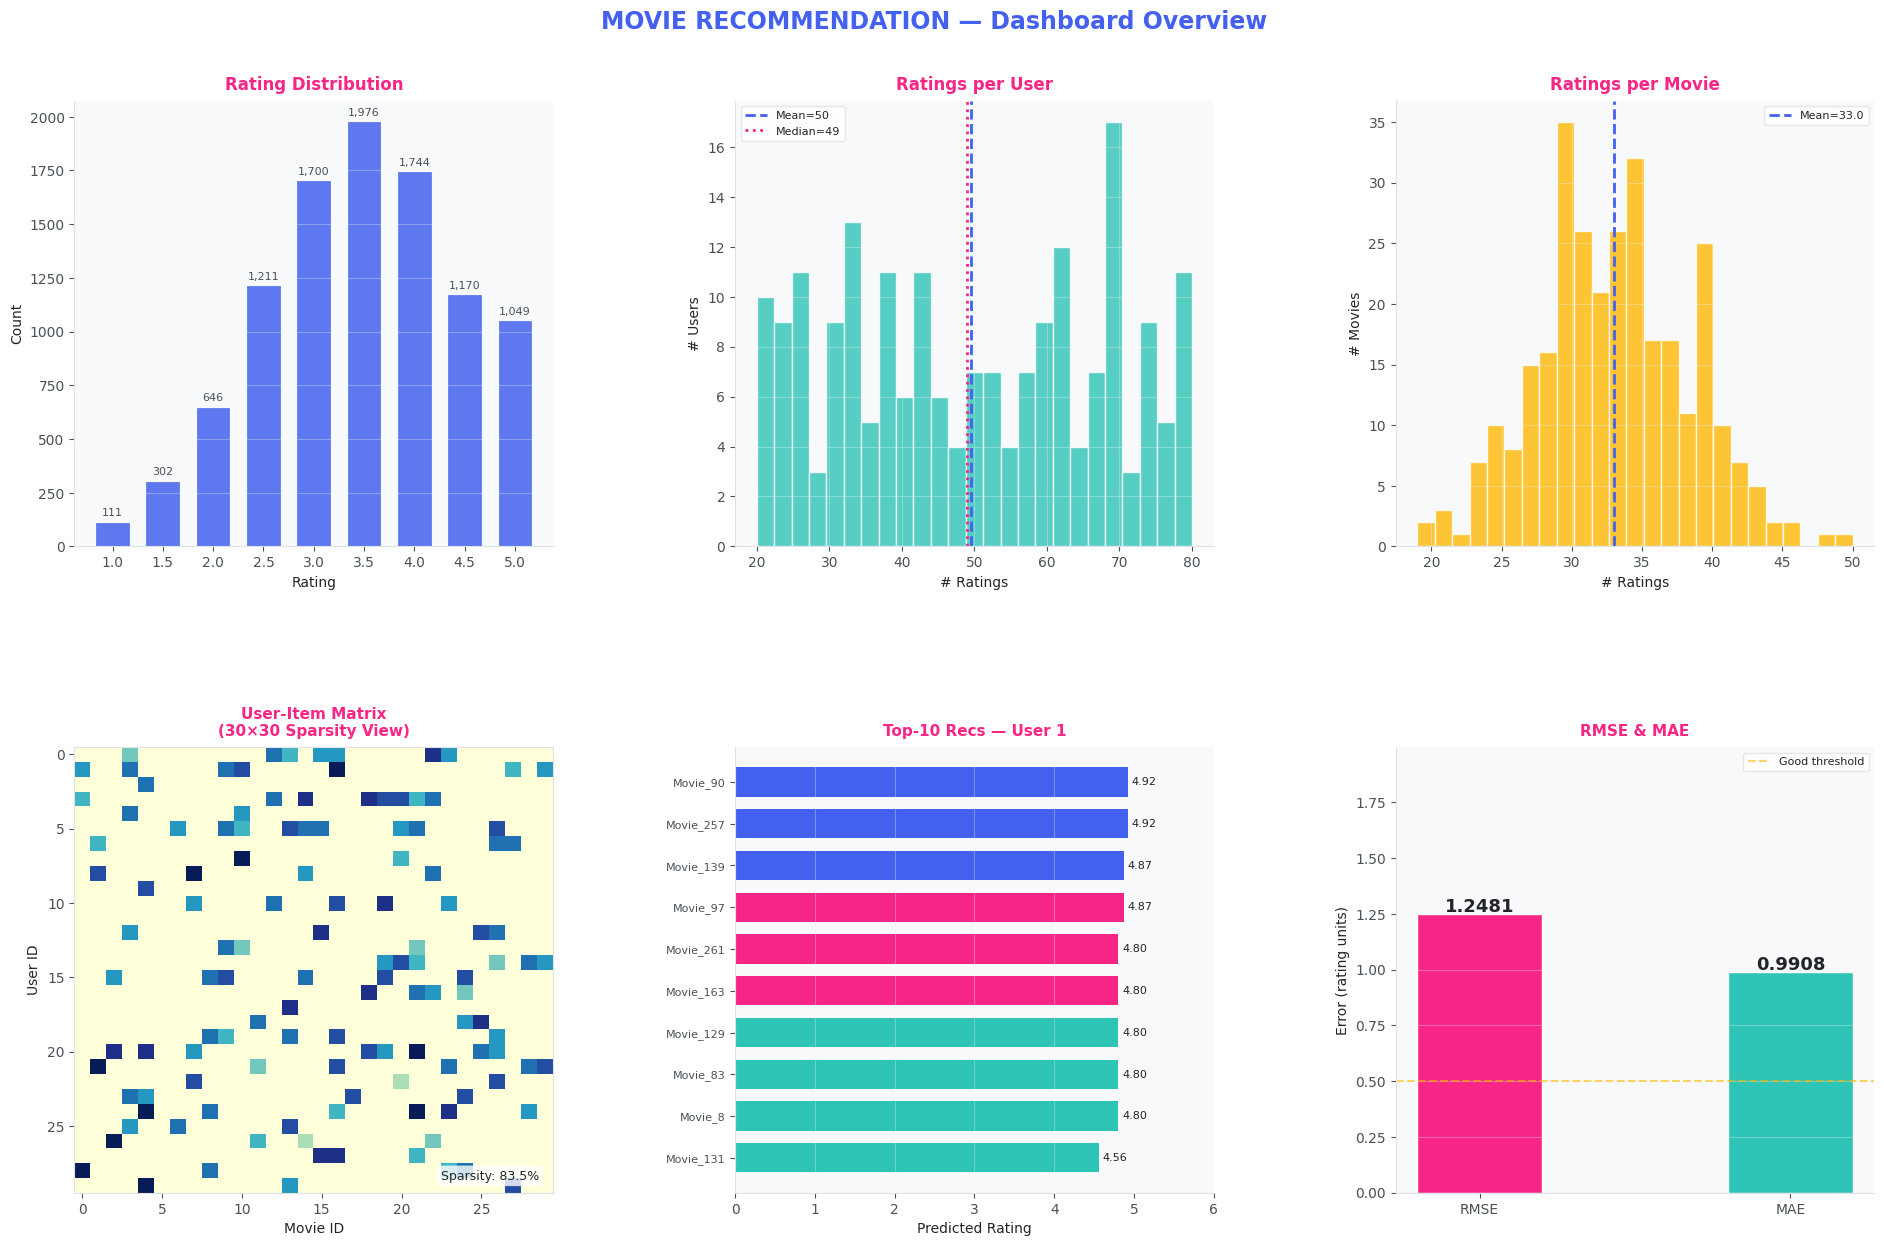

In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Setting the white theme
plt.style.use('default')
plt.rcParams.update({
    "figure.facecolor": "#FFFFFF", "axes.facecolor": "#FFFFFF",
    "text.color": "#212529",       "axes.labelcolor": "#212529",
    "xtick.color": "#495057",      "ytick.color": "#495057",
    "axes.edgecolor": "#DEE2E6",   "grid.color": "#F8F9FA",
    "font.family": "sans-serif",
})

ACCENT, ACCENT2 = "#4361EE", "#F72585"
GOLD, TEAL      = "#FFB703", "#2EC4B6"
BG_WHITE, BG_CARD = "#FFFFFF", "#F8F9FA"

# Initialize Dashboard
fig = plt.figure(figsize=(20, 13), facecolor=BG_WHITE)
fig.suptitle("MOVIE RECOMMENDATION — Dashboard Overview",
             fontsize=17, color=ACCENT, fontweight="bold", y=0.98)

gs_obj = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
                           left=0.07, right=0.97, top=0.91, bottom=0.07)

# 1. Rating distribution
ax1 = fig.add_subplot(gs_obj[0, 0]); ax1.set_facecolor(BG_CARD)
rc_d = ratings["rating"].value_counts().sort_index()
bars = ax1.bar(rc_d.index.astype(str), rc_d.values, color=ACCENT,
               alpha=0.85, edgecolor=ACCENT, linewidth=0.5, width=0.65)
for b, v in zip(bars, rc_d.values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+30, f"{v:,}",
             ha="center", fontsize=8, color="#495057")
ax1.set_title("Rating Distribution", fontsize=12, color=ACCENT2, fontweight="bold", pad=8)
ax1.set_xlabel("Rating"); ax1.set_ylabel("Count")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", alpha=0.3)

# 2. Ratings per user
ax2 = fig.add_subplot(gs_obj[0, 1]); ax2.set_facecolor(BG_CARD)
urc = ratings.groupby("user_id")["rating"].count()
ax2.hist(urc, bins=25, color=TEAL, alpha=0.80, edgecolor="white")
ax2.axvline(urc.mean(), color=ACCENT, lw=2, ls="--", label=f"Mean={urc.mean():.0f}")
ax2.axvline(urc.median(), color=ACCENT2, lw=2, ls=":", label=f"Median={urc.median():.0f}")
ax2.set_title("Ratings per User", fontsize=12, color=ACCENT2, fontweight="bold", pad=8)
ax2.set_xlabel("# Ratings"); ax2.set_ylabel("# Users")
ax2.legend(fontsize=8, facecolor="white", edgecolor="#DEE2E6")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.grid(alpha=0.3)

# 3. Ratings per movie
ax3 = fig.add_subplot(gs_obj[0, 2]); ax3.set_facecolor(BG_CARD)
mrc = ratings.groupby("movie_id")["rating"].count()
ax3.hist(mrc, bins=25, color=GOLD, alpha=0.80, edgecolor="white")
ax3.axvline(mrc.mean(), color=ACCENT, lw=2, ls="--", label=f"Mean={mrc.mean():.1f}")
ax3.set_title("Ratings per Movie", fontsize=12, color=ACCENT2, fontweight="bold", pad=8)
ax3.set_xlabel("# Ratings"); ax3.set_ylabel("# Movies")
ax3.legend(fontsize=8, facecolor="white", edgecolor="#DEE2E6")
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
ax3.grid(alpha=0.3)

# 4. Sparsity view
ax4 = fig.add_subplot(gs_obj[1, 0]); ax4.set_facecolor(BG_CARD)
sub = user_item_raw.iloc[:30, :30].values.copy()
sub = np.nan_to_num(sub, nan=0)
ax4.imshow(sub, cmap="YlGnBu", aspect="auto", interpolation="nearest")
ax4.set_title("User-Item Matrix\n(30×30 Sparsity View)", fontsize=11, color=ACCENT2, fontweight="bold", pad=8)
ax4.set_xlabel("Movie ID"); ax4.set_ylabel("User ID")
ax4.text(0.97, 0.03, f"Sparsity: {sparsity*100:.1f}%", transform=ax4.transAxes,
         ha="right", fontsize=9, color="#212529",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none"))

# 5. Top-10 recommended movies
ax5 = fig.add_subplot(gs_obj[1, 1]); ax5.set_facecolor(BG_CARD)
# Assuming 'recs' and 'DEMO_USER' are defined from previous cells
colors5 = [ACCENT if i<3 else ACCENT2 if i<6 else TEAL for i in range(len(recs))]
bars5 = ax5.barh(range(len(recs)), recs["predicted_rating"],
                 color=colors5, edgecolor="none", height=0.7)
ax5.set_yticks(range(len(recs)))
ax5.set_yticklabels([str(t)[:13] for t in recs["title"]], fontsize=8)
ax5.invert_yaxis(); ax5.set_xlim(0, 6.0)
for b, v in zip(bars5, recs["predicted_rating"]):
    ax5.text(v+0.05, b.get_y()+b.get_height()/2, f"{v:.2f}",
             va="center", fontsize=8, color="#212529")
ax5.set_title(f"Top-10 Recs — User {DEMO_USER}", fontsize=11, color=ACCENT2, fontweight="bold", pad=8)
ax5.set_xlabel("Predicted Rating")
ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)
ax5.grid(axis="x", alpha=0.3)

# 6. RMSE / MAE bar
ax6 = fig.add_subplot(gs_obj[1, 2]); ax6.set_facecolor(BG_CARD)
# Assuming 'rmse' and 'mae' are defined
bm = ax6.bar(["RMSE", "MAE"], [rmse, mae], color=[ACCENT2, TEAL],
             width=0.4, edgecolor="white")
ax6.set_ylim(0, max(rmse, mae) * 1.6)
for b, v in zip(bm, [rmse, mae]):
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f"{v:.4f}", ha="center", fontsize=13, color="#212529", fontweight="bold")
ax6.axhline(0.5, color=GOLD, ls="--", lw=1.5, alpha=0.6, label="Good threshold")
ax6.set_title("RMSE & MAE", fontsize=11, color=ACCENT2, fontweight="bold", pad=8)
ax6.set_ylabel("Error (rating units)")
ax6.legend(fontsize=8, facecolor="white", edgecolor="#DEE2E6")
ax6.spines["top"].set_visible(False); ax6.spines["right"].set_visible(False)
ax6.grid(axis="y", alpha=0.3)

plt.show()


## 🎨 Visualization 2 — Heatmap of User-Item Matrix

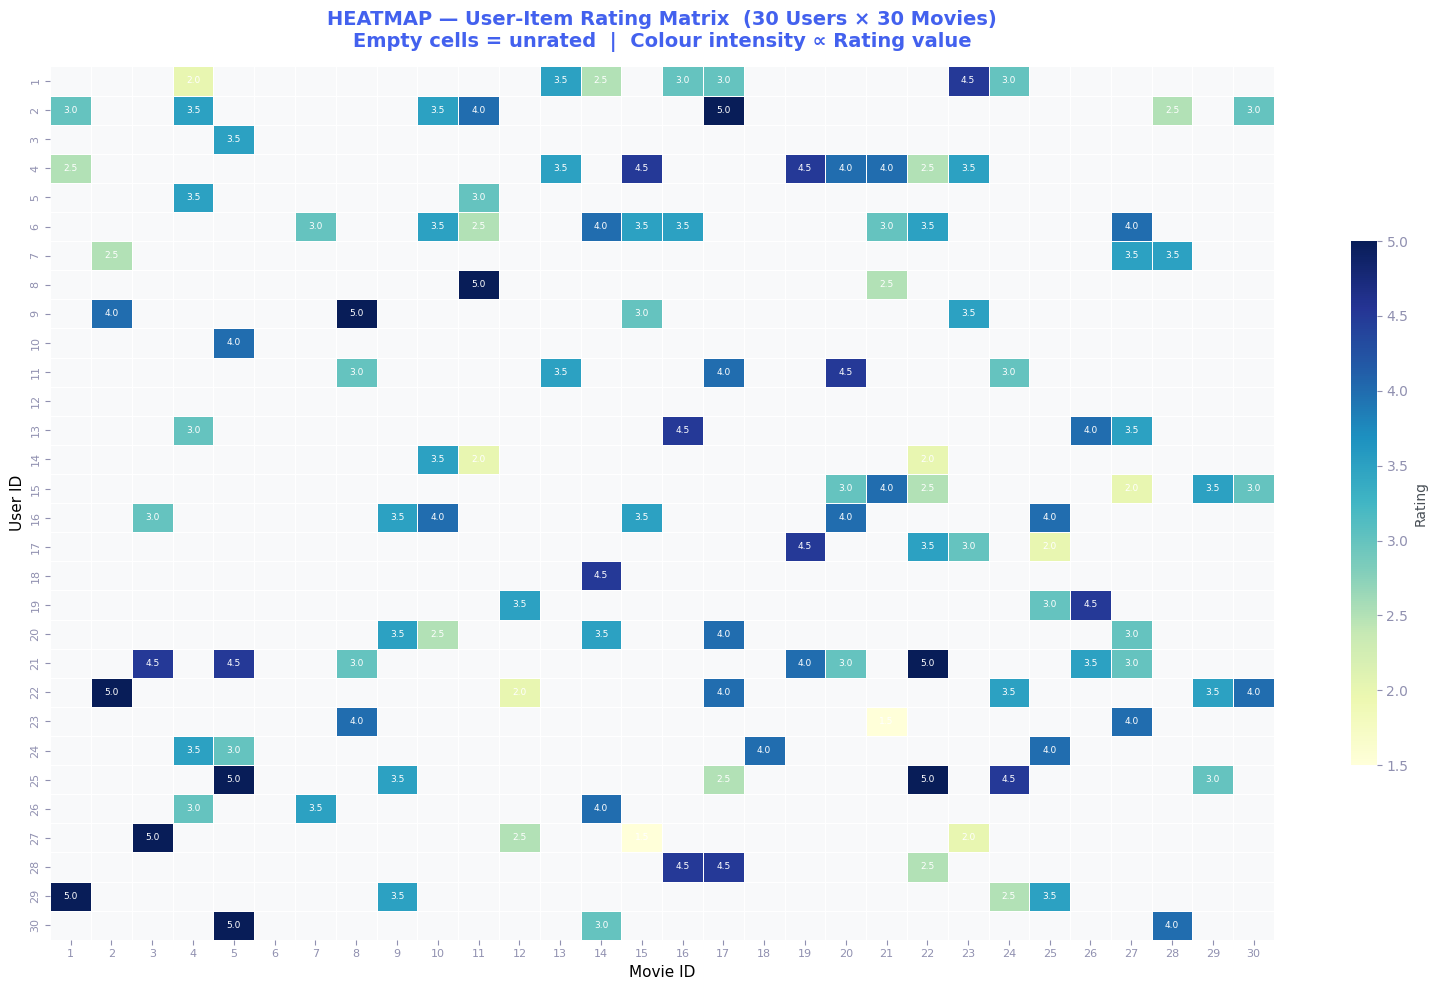

In [57]:
import matplotlib.pyplot as plt
plt.style.use('default')
fig2, ax_h = plt.subplots(figsize=(16, 10), facecolor=BG_WHITE)
ax_h.set_facecolor(BG_WHITE)

sub_ui = user_item_raw.iloc[:30, :30]

sns.heatmap(sub_ui, ax=ax_h, cmap="YlGnBu",
            mask=(sub_ui == 0) | sub_ui.isna(),
            linewidths=0.4, linecolor="#FFFFFF",
            cbar_kws={"shrink": 0.6, "label": "Rating"},
            annot=True, fmt=".1f",
            annot_kws={"size": 6.5, "color": "white"})

ax_h.set_facecolor("#F8F9FA")
ax_h.set_title(
    "HEATMAP — User-Item Rating Matrix  (30 Users × 30 Movies)\n"
    "Empty cells = unrated  |  Colour intensity ∝ Rating value",
    fontsize=14, color=ACCENT, fontweight="bold", pad=14)
ax_h.set_xlabel("Movie ID", fontsize=11); ax_h.set_ylabel("User ID", fontsize=11)
ax_h.tick_params(colors="#9090B0", labelsize=8)

cbar = ax_h.collections[0].colorbar
cbar.ax.yaxis.label.set_color("#495057"); cbar.ax.tick_params(colors="#9090B0")

plt.tight_layout()
plt.show()


## 🎨 Visualization 3 — User Similarity Matrix

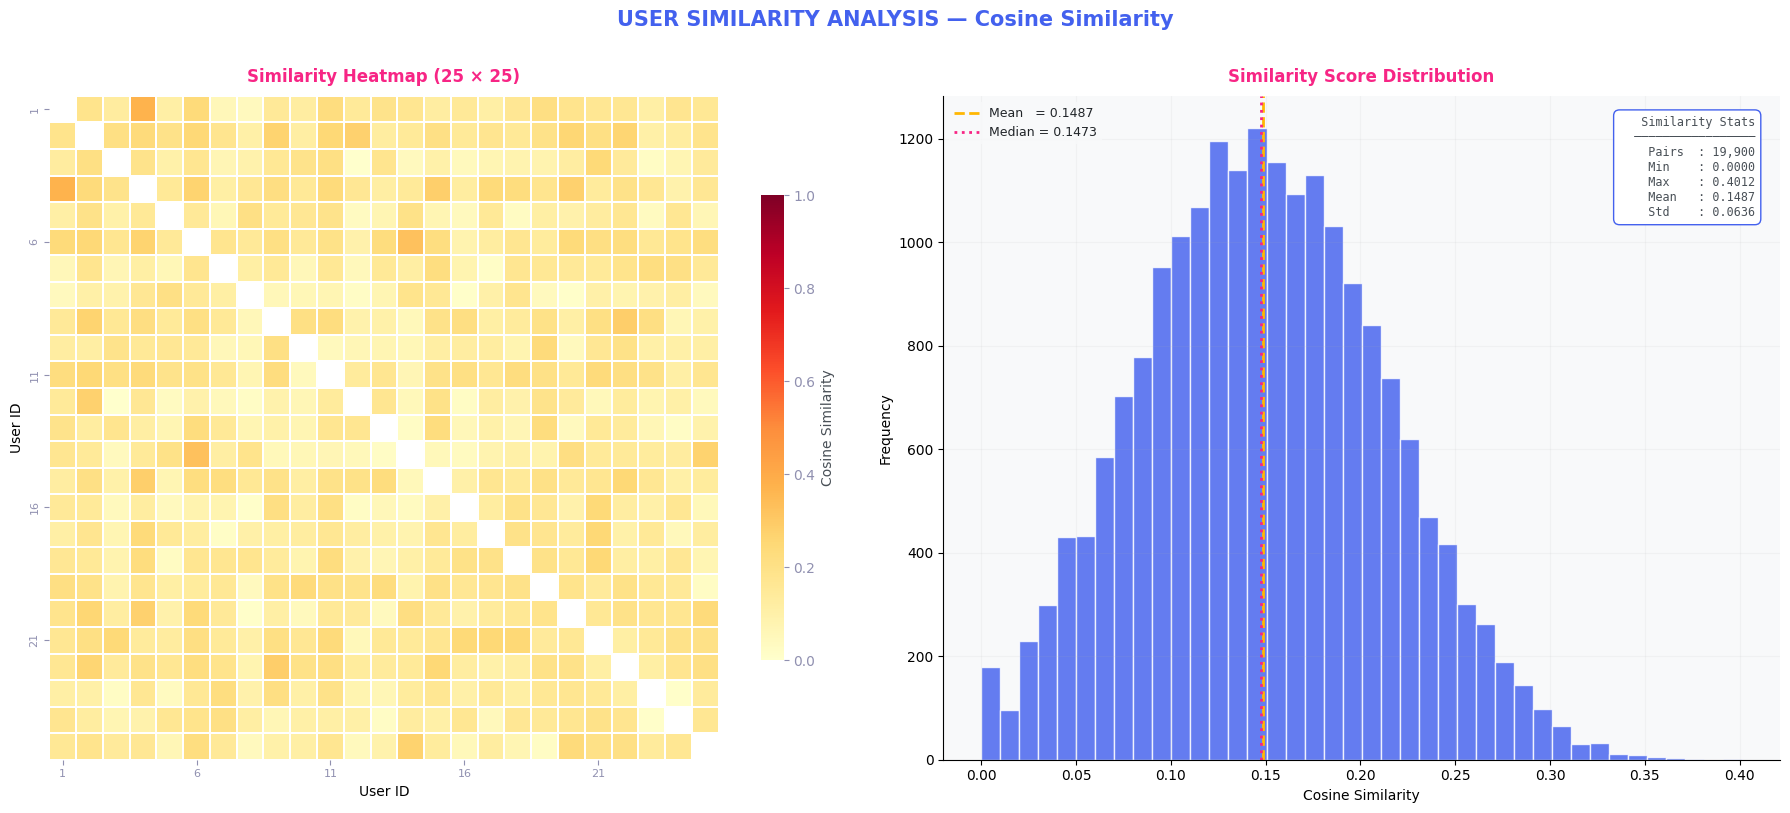

In [58]:
import matplotlib.pyplot as plt
plt.style.use('default')
fig3, axes3 = plt.subplots(1, 2, figsize=(18, 8), facecolor=BG_WHITE)
fig3.suptitle("USER SIMILARITY ANALYSIS — Cosine Similarity",
              fontsize=15, color=ACCENT, fontweight="bold", y=1.01)

# Heatmap
ax_sim = axes3[0]; ax_sim.set_facecolor(BG_WHITE)
sim25  = user_sim_df.iloc[:25, :25]
mask_d = np.eye(25, dtype=bool)
sns.heatmap(sim25, ax=ax_sim, cmap="YlOrRd",
            mask=mask_d, linewidths=0.3, linecolor="#FFFFFF",
            vmin=0, vmax=1,
            cbar_kws={"shrink": 0.7, "label": "Cosine Similarity"},
            xticklabels=5, yticklabels=5)
ax_sim.set_title("Similarity Heatmap (25 × 25)", fontsize=12,
                 color=ACCENT2, fontweight="bold", pad=10)
ax_sim.set_xlabel("User ID"); ax_sim.set_ylabel("User ID")
ax_sim.tick_params(colors="#9090B0", labelsize=8)
cbar3 = ax_sim.collections[0].colorbar
cbar3.ax.yaxis.label.set_color("#495057"); cbar3.ax.tick_params(colors="#9090B0")

# Distribution
ax_d = axes3[1]; ax_d.set_facecolor(BG_CARD)
ax_d.hist(flat_sim, bins=40, color=ACCENT, alpha=0.82, edgecolor="#FFFFFF")
ax_d.axvline(flat_sim.mean(), color=GOLD, lw=2, ls="--",
             label=f"Mean   = {flat_sim.mean():.4f}")
ax_d.axvline(np.median(flat_sim), color=ACCENT2, lw=2, ls=":",
             label=f"Median = {np.median(flat_sim):.4f}")
ax_d.set_title("Similarity Score Distribution", fontsize=12,
               color=ACCENT2, fontweight="bold", pad=10)
ax_d.set_xlabel("Cosine Similarity"); ax_d.set_ylabel("Frequency")
ax_d.legend(fontsize=9, facecolor="#F8F9FA", edgecolor="none", labelcolor="#212529")
ax_d.spines["top"].set_visible(False); ax_d.spines["right"].set_visible(False)
ax_d.grid(alpha=0.1)

stats_box = (f"  Similarity Stats\n"
             f"  ─────────────────\n"
             f"  Pairs  : {len(flat_sim):,}\n"
             f"  Min    : {flat_sim.min():.4f}\n"
             f"  Max    : {flat_sim.max():.4f}\n"
             f"  Mean   : {flat_sim.mean():.4f}\n"
             f"  Std    : {flat_sim.std():.4f}")
ax_d.text(0.97, 0.97, stats_box, transform=ax_d.transAxes, ha="right", va="top",
          fontsize=8.5, fontfamily="monospace", color="#495057",
          bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFFFFF",
                    edgecolor=ACCENT, linewidth=1))

plt.tight_layout()
plt.show()


## 🎨 Visualization 4 — Top Recommended Movies (6 Users)

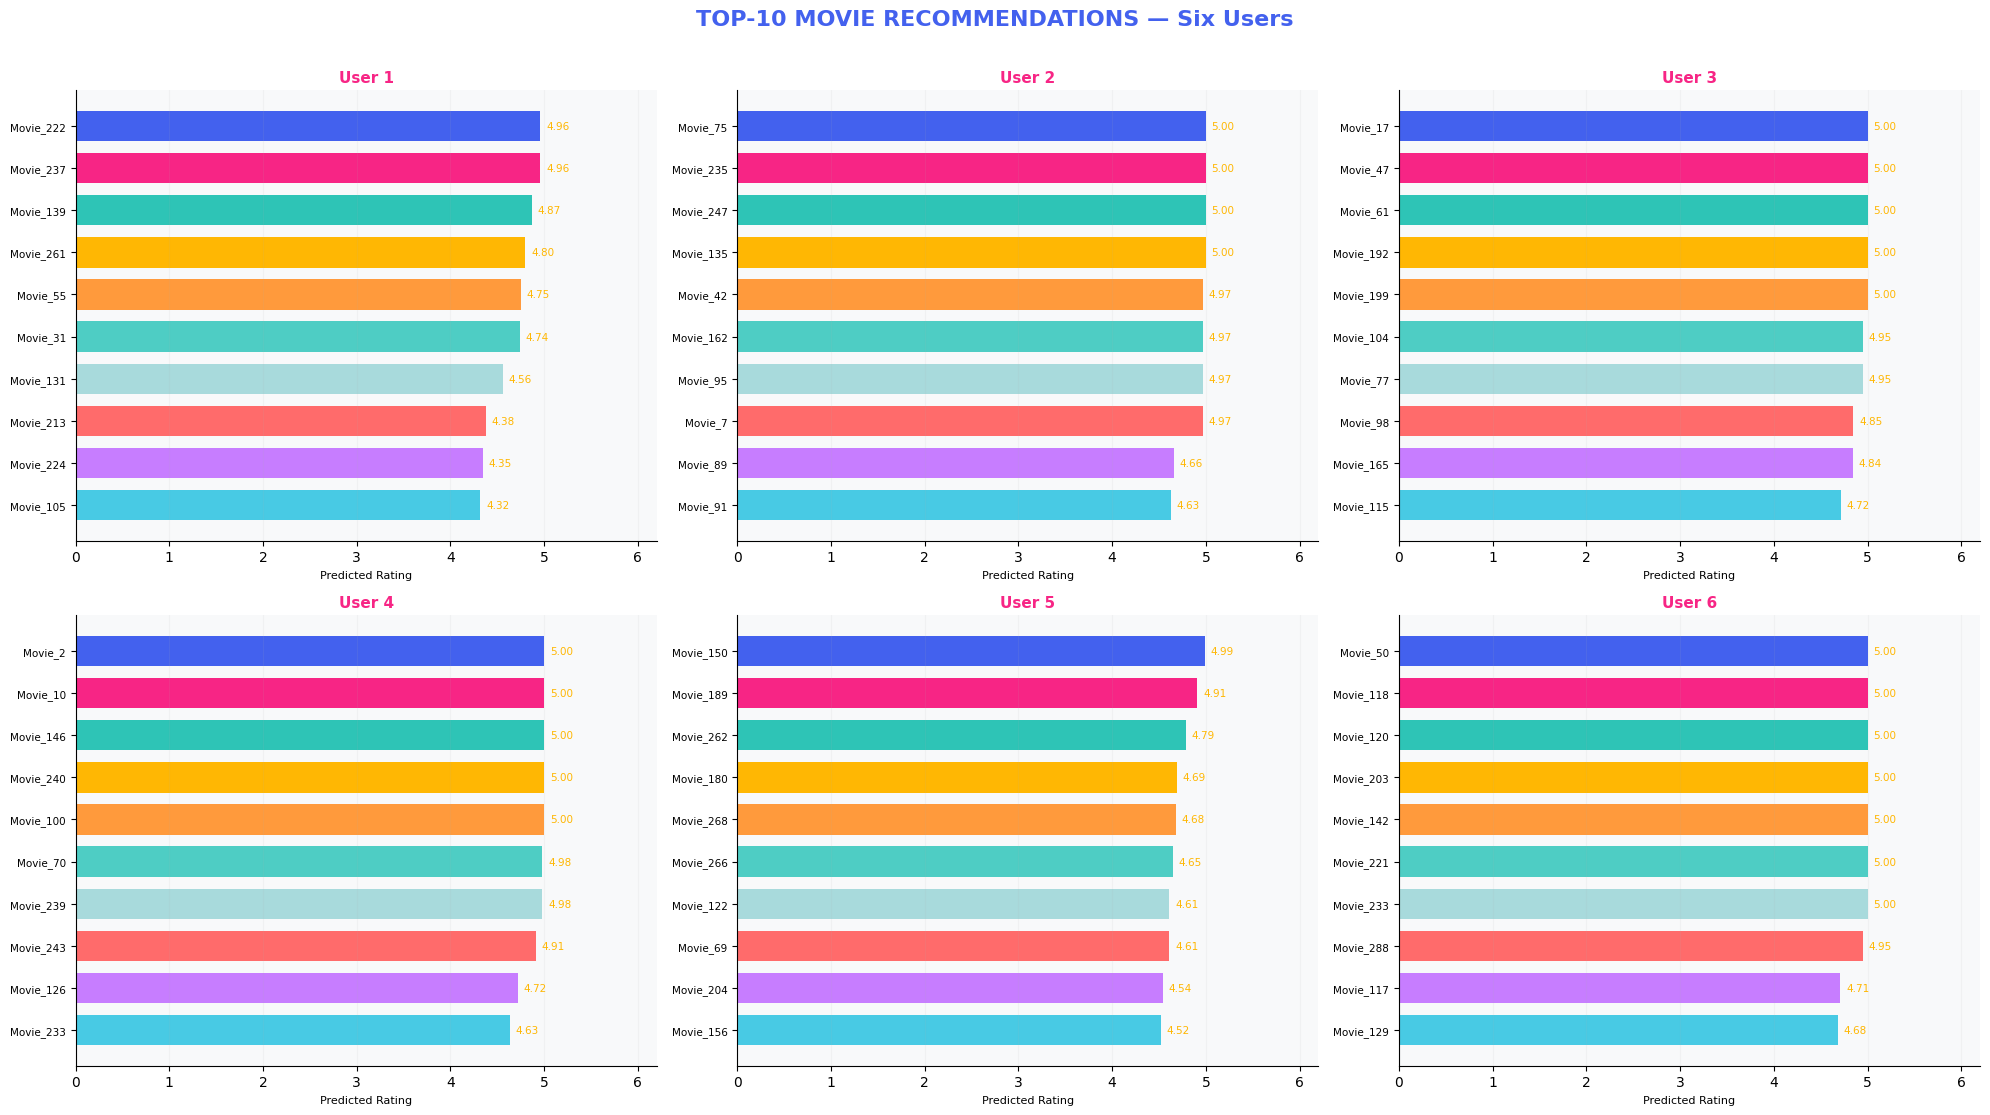

In [59]:
import matplotlib.pyplot as plt
plt.style.use('default')
fig4, axes4 = plt.subplots(2, 3, figsize=(20, 11), facecolor=BG_WHITE)
fig4.suptitle("TOP-10 MOVIE RECOMMENDATIONS — Six Users",
              fontsize=16, color=ACCENT, fontweight="bold", y=1.01)

sample_users = list(user_item_zero.index[:6])
palette = [ACCENT, ACCENT2, TEAL, GOLD, "#FF9A3C",
           "#4ECDC4", "#A8DADC", "#FF6B6B", "#C77DFF", "#48CAE4"]

for uid, ax_r in zip(sample_users, axes4.flat):
    ax_r.set_facecolor(BG_CARD)
    u_recs = recommend_movies(uid, user_item_zero, user_sim_df,
                              movies_df, k=10, top_n=10)
    if u_recs.empty:
        ax_r.text(0.5, 0.5, "No recs", ha="center", va="center",
                  color="#888888", fontsize=12)
        ax_r.axis("off"); continue

    bars_r = ax_r.barh(range(len(u_recs)), u_recs["predicted_rating"],
                       color=palette[:len(u_recs)], edgecolor="none", height=0.72)
    ax_r.set_yticks(range(len(u_recs)))
    ax_r.set_yticklabels([str(t)[:13] for t in u_recs["title"]], fontsize=7.5)
    ax_r.invert_yaxis(); ax_r.set_xlim(0, 6.2)
    for b, v in zip(bars_r, u_recs["predicted_rating"]):
        ax_r.text(v+0.06, b.get_y()+b.get_height()/2,
                  f"{v:.2f}", va="center", fontsize=7.5, color=GOLD)
    ax_r.set_title(f"User {uid}", fontsize=11, color=ACCENT2, fontweight="bold", pad=6)
    ax_r.set_xlabel("Predicted Rating", fontsize=8)
    ax_r.spines["top"].set_visible(False); ax_r.spines["right"].set_visible(False)
    ax_r.grid(axis="x", alpha=0.1)

plt.tight_layout()
plt.show()


## ✅ Summary & Conclusions

In [60]:
print("=" * 56)
print("  FINAL SUMMARY — KNN Movie Recommendation System")
print("=" * 56)
print(f"Dataset: {n_ratings:,} ratings | {n_users} users | {n_movies_total} movies")
print(f"Sparsity      : {sparsity*100:.2f}%")
print(f"Method        : User-Based CF (Cosine Similarity)  K={K}")
print(f"RMSE          : {rmse:.4f}    MAE : {mae:.4f}")



  FINAL SUMMARY — KNN Movie Recommendation System
Dataset: 9,909 ratings | 200 users | 300 movies
Sparsity      : 83.48%
Method        : User-Based CF (Cosine Similarity)  K=5
RMSE          : 1.2481    MAE : 0.9908
